키워드 분석이란 불용어 제거와 어간추출 및 형태소 분석 등의 자연어 처리를 시행한 후 텍스트에서 많이 등장하는 형태소의 등장 빈도를 분석함으로써 핵심어를 추출

In [ ]:
import matplotlib.font_manager as fm
import os
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# apt-get : 패키지 설치 명령어
# -qq : 에러외의 메세지 숨기는 옵션키
!apt-get -qq install fonts-nanum

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) # 폰트 설정


Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


한국어 자연어 처리 konlpy와 형태소 분석기 MeCab() 설치

In [ ]:
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git

Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 2.62 MiB/s, done.
Resolving deltas: 100% (65/65), done.


In [ ]:
%cd Mecab-ko-for-Google-Colab/

/content/Mecab-ko-for-Google-Colab


In [ ]:
ls

images/                                    LICENSE
install_mecab-ko_on_colab190912.sh         README.md
install_mecab-ko_on_colab_light_220429.sh


In [ ]:
!bash install_mecab-ko_on_colab_light_220429.sh

Installing konlpy.....
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 30.1 MB/s eta 0:00:00
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-04-08 05:03:46--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.134, 13.200.41.135, 13.200.41.136, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.134|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-08 05:03:46 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make install
ldconfig
Done
Change Dir

pos 메서드를 사용하여 문장을 형태소 단위로 분할하고 각 형태소의 품사를 태깅합니다. 결과는 형태소와 품사의 튜플로 이루어진 리스트 형태로 반환됩니다.

- MAG: 일반 부사 (e.g., '언제나')
- NNG: 일반 명사 (e.g., '현재', '집중', '행복')
- JKB: 부사격 조사 (e.g., '에')
- XSV+ETM: 동사 파생 접미사 + 관형형 전성 어미 (e.g., '할')
- NNB: 의존 명사 (e.g., '수', '것')
- VV: 동사 (e.g., '있')
- EC: 연결 어미 (e.g., '다면')
- VCP: 긍정 지정사 (e.g., '이')
- EF: 종결 어미 (e.g., '다')
- SF: 마침표, 물음표, 느낌표 (e.g., '.')

In [ ]:
from konlpy.tag import Mecab

tagger = Mecab()

sentence = '언제나 현재에 집중할 수 있다면 행복할 것이다.'
tagger.pos(sentence)

[('언제나', 'MAG'),
 ('현재', 'NNG'),
 ('에', 'JKB'),
 ('집중', 'NNG'),
 ('할', 'XSV+ETM'),
 ('수', 'NNB'),
 ('있', 'VV'),
 ('다면', 'EC'),
 ('행복', 'NNG'),
 ('할', 'XSV+ETM'),
 ('것', 'NNB'),
 ('이', 'VCP'),
 ('다', 'EF'),
 ('.', 'SF')]

네이버 영화 리뷰 데이터
키워드 분석 예제로 이 데이터 사용
데이터 다운로드 https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt


In [ ]:
import urllib.request

raw = urllib.request.urlopen('https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt').readlines()  # 라인별로
print(raw[:3])
print(type(raw))

[b'id\tdocument\tlabel\n', b'8112052\t\xec\x96\xb4\xeb\xa6\xb4\xeb\x95\x8c\xeb\xb3\xb4\xea\xb3\xa0 \xec\xa7\x80\xea\xb8\x88\xeb\x8b\xa4\xec\x8b\x9c\xeb\xb4\x90\xeb\x8f\x84 \xec\x9e\xac\xeb\xb0\x8c\xec\x96\xb4\xec\x9a\x94\xe3\x85\x8b\xe3\x85\x8b\t1\n', b'8132799\t\xeb\x94\x94\xec\x9e\x90\xec\x9d\xb8\xec\x9d\x84 \xeb\xb0\xb0\xec\x9a\xb0\xeb\x8a\x94 \xed\x95\x99\xec\x83\x9d\xec\x9c\xbc\xeb\xa1\x9c, \xec\x99\xb8\xea\xb5\xad\xeb\x94\x94\xec\x9e\x90\xec\x9d\xb4\xeb\x84\x88\xec\x99\x80 \xea\xb7\xb8\xeb\x93\xa4\xec\x9d\xb4 \xec\x9d\xbc\xea\xb5\xb0 \xec\xa0\x84\xed\x86\xb5\xec\x9d\x84 \xed\x86\xb5\xed\x95\xb4 \xeb\xb0\x9c\xec\xa0\x84\xed\x95\xb4\xea\xb0\x80\xeb\x8a\x94 \xeb\xac\xb8\xed\x99\x94\xec\x82\xb0\xec\x97\x85\xec\x9d\xb4 \xeb\xb6\x80\xeb\x9f\xac\xec\x9b\xa0\xeb\x8a\x94\xeb\x8d\xb0. \xec\x82\xac\xec\x8b\xa4 \xec\x9a\xb0\xeb\xa6\xac\xeb\x82\x98\xeb\x9d\xbc\xec\x97\x90\xec\x84\x9c\xeb\x8f\x84 \xea\xb7\xb8 \xec\x96\xb4\xeb\xa0\xa4\xec\x9a\xb4\xec\x8b\x9c\xec\xa0\x88\xec\x97\x90 \xeb\x81\x9d

데이터를 보면 모두 바이트로 되어있고 리뷰외에 다른 데이터도 존재
데이터를 문자열로 변환하고 리뷰만 추출

x.decode()는 UTF-8 또는 다른 특정 인코딩 형식으로 디코딩하여 문자열로 변환하는 작업을 수행합니다

decode 함수는 인코딩 방식을 명시하지 않으면 시스템의 기본 인코딩 방식을 따르게 됩니다. 대부분의 경우 기본 인코딩은 UTF-8

In [ ]:
raw = [x.decode() for x in raw[1:]]  # raw[0]는 컬럼명
reviews = []

for line in raw :
  reviews.append(line.split('\t')[1]) # 라인에서 2번째 항목이 리뷰임

print(reviews[:5])

['어릴때보고 지금다시봐도 재밌어요ㅋㅋ', '디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업이 부러웠는데. 사실 우리나라에서도 그 어려운시절에 끝까지 열정을 지킨 노라노 같은 전통이있어 저와 같은 사람들이 꿈을 꾸고 이뤄나갈 수 있다는 것에 감사합니다.', '폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.', '와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런게 진짜 영화지', '안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.']


형태소 분석을 이용한 명사 추출


In [ ]:
from konlpy.tag import Mecab

tagger = Mecab()

nouns = []

for review in reviews :
  for noun in tagger.nouns(review) :
    nouns.append(noun)

print(nouns[:20])

['때', '디자인', '학생', '외국', '디자이너', '그', '전통', '발전', '문화', '산업', '우리', '나라', '시절', '끝', '열정', '노라노', '전통', '저', '사람', '꿈']


In [ ]:
print(len(nouns))

1067552


불용어(Stopwords) 사전 만들기

In [ ]:
stop_words = "영화 전 난 일 걸 뭐 줄 만 건 분 개 끝 잼 이거 번 중 듯 때 게 내 말 나 수 거 점 것"
stop_words = stop_words.split()
print(stop_words)

['영화', '전', '난', '일', '걸', '뭐', '줄', '만', '건', '분', '개', '끝', '잼', '이거', '번', '중', '듯', '때', '게', '내', '말', '나', '수', '거', '점', '것']


불용어를 제외한 명사들을 nouns에 저장

In [ ]:
nouns = []

for review in reviews :
  for noun in tagger.nouns(review) :
    if noun not in stop_words :
      nouns.append(noun)

print(nouns[:10])

['디자인', '학생', '외국', '디자이너', '그', '전통', '발전', '문화', '산업', '우리']


In [ ]:
len(nouns)

856808

단어 빈도수 측정 : nltk.FreqDist() 함수를 이용

In [ ]:
import nltk

word_freq = nltk.FreqDist(nouns)
word_freq

FreqDist({'연기': 9174, '최고': 8811, '평점': 8513, '스토리': 7165, '생각': 6919, '드라마': 6889, '사람': 6741, '감동': 6489, '배우': 5877, '내용': 5731, ...})

단어 빈도수 측정 : collections 라이브러리의 Counter() 함수를 이용

In [ ]:
from collections import Counter

nouns_counter = Counter(nouns)
print(nouns_counter.most_common(5))
top_nouns = dict(nouns_counter.most_common(50))
print(top_nouns)

[('연기', 9174), ('최고', 8811), ('평점', 8513), ('스토리', 7165), ('생각', 6919)]
{'연기': 9174, '최고': 8811, '평점': 8513, '스토리': 7165, '생각': 6919, '드라마': 6889, '사람': 6741, '감동': 6489, '배우': 5877, '내용': 5731, '감독': 5628, '재미': 5476, '시간': 5324, '년': 4934, '사랑': 4742, '쓰레기': 4584, '작품': 3982, '하나': 3878, '정도': 3659, '마지막': 3647, '이건': 3595, '액션': 3568, '기대': 3477, '장면': 3262, '편': 3044, '이게': 3020, '최악': 3017, '돈': 2981, '이야기': 2947, '애': 2717, '명작': 2685, '처음': 2684, '여자': 2677, '이해': 2671, '이상': 2643, '한국': 2633, '주인공': 2554, '우리': 2532, '연출': 2376, '때문': 2371, '기억': 2364, '현실': 2191, '마음': 2128, '굿': 2110, '남자': 2078, '결말': 2066, '인생': 2056, '공포': 2046, '전개': 2035, '짜증': 2011}


단어 빈도 시각화

plt.barh(y_pos, top_nouns.values()) 함수 호출에서:

y_pos는 y 축에서 막대들이 위치할 좌표를 지정합니다.
top_nouns.values()는 각 막대의 너비를 지정합니다.

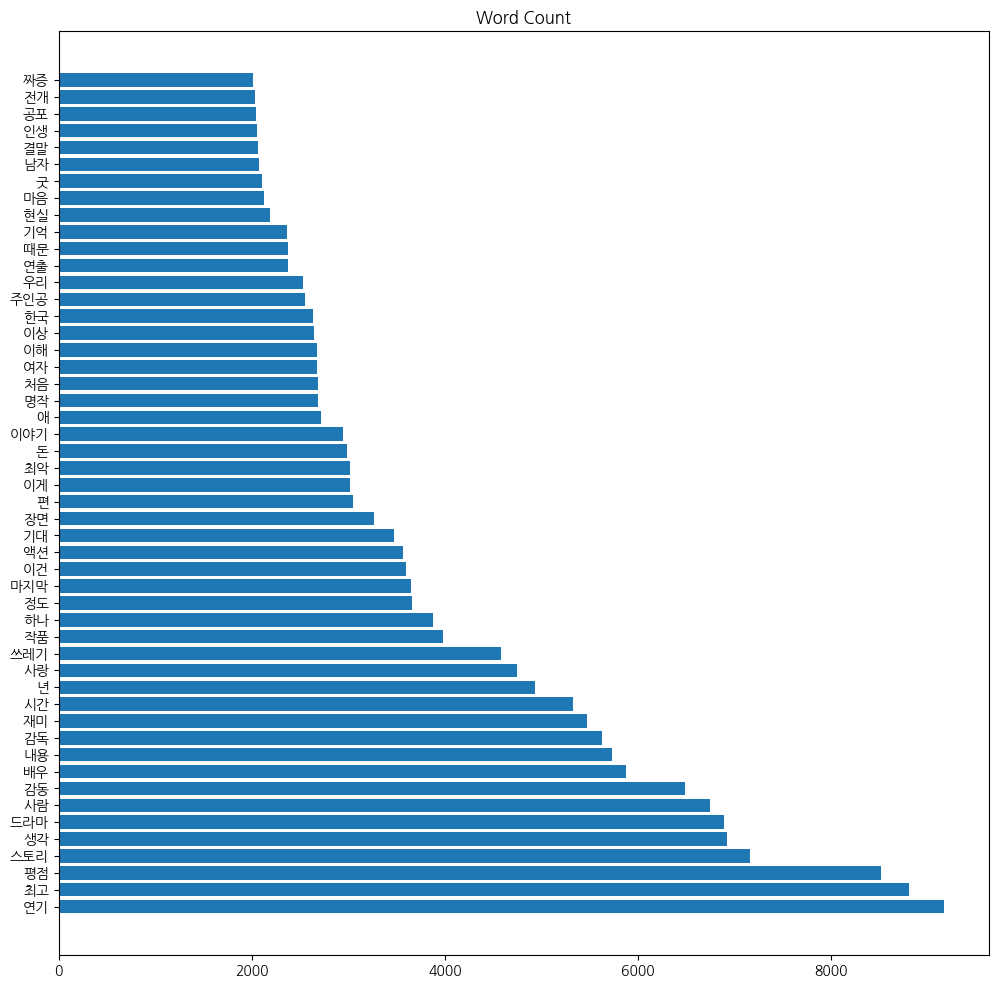

In [ ]:
import numpy as np

y_pos = np.arange(len(top_nouns))
plt.figure(figsize = (12, 12))
plt.barh(y_pos, top_nouns.values())  # bar 형태의 히스토그램
plt.title("Word Count")
plt.yticks(y_pos, top_nouns.keys())
plt.show()


워드클라우드(WordCloud) : 워드 클라우드는 텍스트 데이터의 시각적 표현 방법 중 하나로, 텍스트에서 가장 많이 등장하는 단어들을 크기와 색상으로 강조하여 나타낸 그래픽입니다

In [ ]:
!pip install wordcloud

WordCloud를 이용해 객체를 생성해주고 generate_from_frequencies() 함수로 빈도수에 따라 워드클라우드를 생성

단어들 사이의 연관성이나 의미구조 등을 분석하는데는 한계가 있음

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(background_color = 'yellow', font_path = './font/NanumBarunGothic.ttf')
wc.generate_from_frequencies(top_nouns)

이미지 시각화 함수인 imshow() 함수를 사용해 워드 클라우드를 시각화

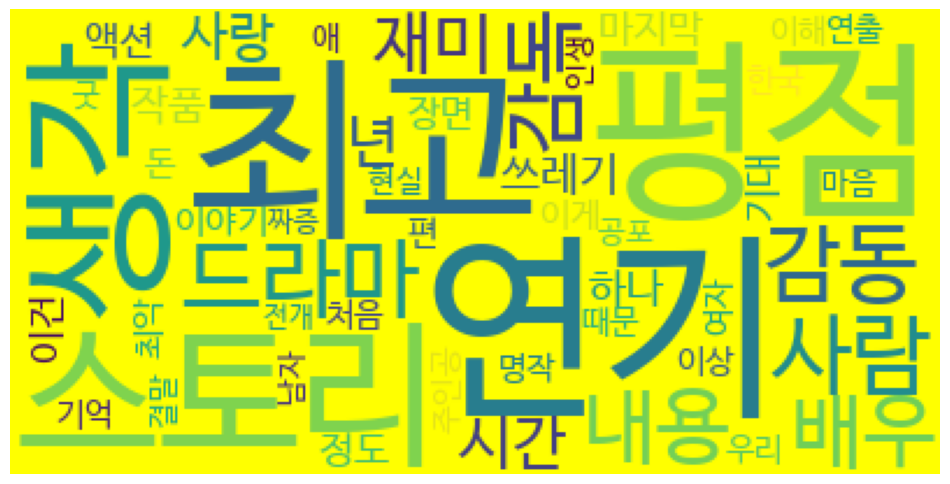

In [ ]:
figure = plt.figure(figsize=(12,12))
ax = figure.add_subplot(1, 1, 1)
ax.axis('off')
ax.imshow(wc)
plt.show()

squarify 트리맵 시각화
- squarify는 트리맵을 생성을 지원해 주는 파이썬 라이브러리
- squarify 라이브러리를 이용해 키워드와 키워드 빈도수를 트리맵으로 나타냄

In [ ]:
!pip install squarify

<Axes: >

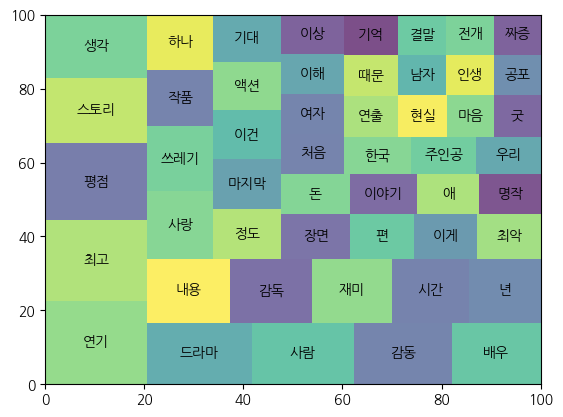

In [ ]:
import matplotlib as mpl
import squarify

squarify.plot(label=top_nouns.keys(), sizes = top_nouns.values(), alpha=0.7)

<Axes: >

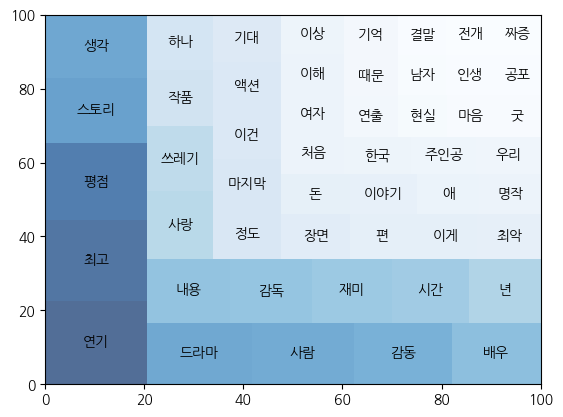

In [ ]:
norm = mpl.colors.Normalize(vmin=min(top_nouns.values()), vmax=max(top_nouns.values()) )
colors = [mpl.cm.Blues(norm(value)) for value in top_nouns.values()]

squarify.plot(label=top_nouns.keys(), sizes = top_nouns.values(), color=colors, alpha=0.7)